# Introduction to Scikit learn (sklearn)

This notebook demonstrate some of the useful and most beautiful Scikitlearn library

What we're going to learn :

0. An end-to-end Scikit-learn workflow
1. Getting the data ready
2. Choose the right estimator/algorithm for our problems
3. Fit the model/algorithm and use it to make prediction on our data
4. Evaluating a model
5. Improve a model
6. Save and load a trained model
7. Putting it all together

## 0. An end-to-end Scikit-learn workflow

In [222]:
# Get the data ready
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
heart_disease = pd.read_csv("./csv_datasets/heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [224]:
# Create X (features metrix)
X = heart_disease.drop("target" , axis = 1)

# Create y (labels)
y = heart_disease["target"]

In [225]:
# Choose the right model and hyperparametes
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

# We'll keep the default hyperparameters
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [226]:
# Fit the model to the training data
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X, y , test_size = 0.2)

In [227]:
clf.fit(X_train , y_train);

In [228]:
y_preds = clf.predict(X_test)
y_preds

array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0])

In [229]:
y_test

120    1
247    0
152    1
204    0
40     1
      ..
87     1
58     1
298    0
141    1
190    0
Name: target, Length: 61, dtype: int64

In [230]:
# Make a prediction 
#y_label = clf.predict(np.array([0,2,3,4])) - this is't the same size for predicted arr

In [231]:
# Evaluate the model
clf.score(X_train , y_train)

1.0

In [232]:
clf.score(X_test, y_test)

0.8360655737704918

In [233]:
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score

In [234]:
print(classification_report(y_test , y_preds))

              precision    recall  f1-score   support

           0       0.85      0.79      0.82        29
           1       0.82      0.88      0.85        32

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



In [235]:
confusion_matrix(y_test , y_preds)

array([[23,  6],
       [ 4, 28]])

In [236]:
accuracy_score(y_test , y_preds)

0.8360655737704918

In [237]:
# Improve the model  
# Try different amount of n_estimators
np.random.seed(42)
for i in range (10 , 100 , 10) : 
    print(f"Trying model with {i} estimators ...")
    clf = RandomForestClassifier(n_estimators=i).fit(X_train , y_train)
    print(f"Model accuracy on test set : {clf.score(X_test , y_test) * 100:.2f}%")

Trying model with 10 estimators ...
Model accuracy on test set : 83.61%
Trying model with 20 estimators ...
Model accuracy on test set : 83.61%
Trying model with 30 estimators ...
Model accuracy on test set : 86.89%
Trying model with 40 estimators ...
Model accuracy on test set : 80.33%
Trying model with 50 estimators ...
Model accuracy on test set : 85.25%
Trying model with 60 estimators ...
Model accuracy on test set : 81.97%
Trying model with 70 estimators ...
Model accuracy on test set : 83.61%
Trying model with 80 estimators ...
Model accuracy on test set : 81.97%
Trying model with 90 estimators ...
Model accuracy on test set : 85.25%


In [238]:
# Save a model and load it
import pickle

pickle.dump(clf , open("random_forest_model_1.pkl" , "wb"))

In [239]:
laoded_model = pickle.load(open("random_forest_model_1.pkl" , "rb"))
laoded_model.score(X_test , y_test)

0.8524590163934426

 ## 1. Getting our data ready to be used with machine learning 

 The main thigs we have to do : 
 1. Split the data into features and labels (usually `X` & `y`)
 2. Filling (also called imputing) or disregarding missing values 
 3. Converting non-numerical values to numerical values (also called feature encoding)

In [240]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [241]:
X = heart_disease.drop("target" , axis = 1)
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [242]:
y = heart_disease["target"] 
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [243]:
# Split the data into training and test sets

from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X, y, test_size = 0.2)

In [244]:
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((242, 13), (61, 13), (242,), (61,))

### 1. Make sure it's all numerical 

In [245]:
car_sales = pd.read_csv('./csv_datasets/scikit-learn-data/car-sales-extended.csv')
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [246]:
len(car_sales)

1000

In [247]:
# Split into X/y
X = car_sales.drop("Price" , axis = 1)
y = car_sales["Price"]

# Split into training and test
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)

In [248]:
# Build machine learning model
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make" , "Colour" , "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot" , one_hot , categorical_features)] , remainder = "passthrough")

transformed_X = transformer.fit_transform(X)
transformed_X


array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]], shape=(1000, 13))

In [249]:
pd.DataFrame(transformed_X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [250]:
dummies = pd.get_dummies(car_sales[["Make" , "Colour" , "Doors"]])
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


In [251]:
# let's refit the model

model = RandomForestRegressor()
np.random.seed(42)
X_train , X_test , y_train , y_test = train_test_split(transformed_X , y , test_size=0.2)
model.fit(X_train , y_train)
model.score(X_test , y_test)

0.3235867221569877

### 1.2 What if there were missing values ?

1. Fill them with some value (also known as imputation)
2. Remove the samples with missing data

In [252]:
# Import car sales missing data 
car_sales_missing = pd.read_csv("./csv_datasets/scikit-learn-data/car-sales-extended-missing-data.csv")
car_sales_missing.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [253]:
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [254]:
# Create X & y
X = car_sales_missing.drop("Price" , axis = 1)
y = car_sales_missing["Price"]  

In [255]:
car_sales_missing["Doors"].value_counts()

Doors
4.0    811
5.0     75
3.0     64
Name: count, dtype: int64

In [256]:
#car_sales_price = car_sales_missing["Price"].str.replace(r"[^\d.]" , "" , regex=True).astype(float)
#car_sales_missing["Price"] = car_sales_missing
#print(car_sales_price)

#### Option 1 : Fill missing data with Pandas

In [257]:
# Fill the "Make" column
car_sales_missing["Make"] = car_sales_missing["Make"].fillna("missing")

# Fill the "Colour" column 
car_sales_missing["Colour"] = car_sales_missing["Colour"].fillna("missing")

# Fill the "Odometer (KM)"
car_sales_missing["Odometer (KM)"] = car_sales_missing["Odometer (KM)"].fillna(car_sales_missing["Odometer (KM)"].mean())

# Fill the "Doors" 
car_sales_missing["Doors"] = car_sales_missing["Doors"].fillna(4)


In [258]:
# Remove rows with missing Price value
car_sales_missing.dropna(inplace=True)

In [259]:
car_sales_missing.head()
car_sales_missing.isna().sum()

Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [260]:
len(car_sales_missing)

950

In [261]:
X = car_sales_missing.drop("Price" , axis=1)
y = car_sales_missing["Price"] 

In [262]:
categorical_features = ["Make" , "Colour" , "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot" , one_hot , categorical_features)] , remainder = "passthrough")

transformed_X = transformer.fit_transform(car_sales_missing)
transformed_X


array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        3.54310e+04, 1.53230e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        1.92714e+05, 1.99430e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        8.47140e+04, 2.83430e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.66040e+04, 3.15700e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.15883e+05, 4.00100e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.48360e+05, 1.27320e+04]], shape=(950, 16))

### Option 2 : Fill missing data with Scikit-Learn

In [263]:
car_sales_missing = pd.read_csv("./csv_datasets/scikit-learn-data/car-sales-extended-missing-data.csv")
car_sales_missing.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [264]:
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [265]:
# Drop the rows with no labels
car_sales_missing.dropna(subset=["Price"] , inplace=True)
car_sales_missing.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

In [266]:
# Split into X & y
X = car_sales_missing.drop("Price" , axis=1)
y = car_sales_missing["Price"]

In [267]:
# Fill missing values with Scikit-learn
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Fill categorical values with 'missing' & numerical values with mean
car_imputer = SimpleImputer(strategy="constant" , fill_value="missing")
door_imputer = SimpleImputer(strategy="constant" , fill_value=4)
num_imputer = SimpleImputer(strategy="mean")

# Define columns
car_features=["Make" , "Colour"]
door_features=["Doors"]
num_features=["Odometer (KM)"]

# Create an imputer (something that fills missing data)
imputer = ColumnTransformer([("car_imputer" , car_imputer , car_features),
                             ("door_imputer" , door_imputer , door_features),
                             ("num_imputer" , num_imputer , num_features)])

# Transfom the data
filled_X = imputer.fit_transform(X)
filled_X

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], shape=(950, 4), dtype=object)

In [268]:
car_sales_filled = pd.DataFrame(filled_X , columns = ["Make" , "Colour" , "Doors" , "Odometer (KM)"])
car_sales_filled.head()

,Make,Colour,Doors,Odometer (KM)
0,Honda,White,4.0,35431.0
1,BMW,Blue,5.0,192714.0
2,Honda,White,4.0,84714.0
3,Toyota,White,4.0,154365.0
4,Nissan,Blue,3.0,181577.0


In [269]:
car_sales_filled.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

In [270]:
categorical_features = ["Make" , "Colour" , "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot" , one_hot , categorical_features)] , remainder = "passthrough")

transformed_X = transformer.fit_transform(car_sales_filled)
transformed_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3800 stored elements and shape (950, 15)>

In [271]:
# Now we've got our data as numbers and filled (no missing values)
# Let't fit a model

model = RandomForestRegressor()
np.random.seed(42)
X_train , X_test , y_train , y_test = train_test_split(transformed_X , y , test_size=0.2)
model.fit(X_train , y_train)
model.score(X_test , y_test)

0.21990196728583944

In [272]:
len(car_sales_filled) , len(car_sales)

(950, 1000)

 ## 2. Choosing the right estimator/algorithm for your problem

 Some things to note :
* Sklearn refers to machine learning model , algorithms as estimators .
* Classification problem - predicting a category (heart disease or not)
* Sometimes you'll see 'clf' (short of classifier) used as a classification estimator
* Regression problem - predicting a number (selling price of a car)
    

### 2.1 Picking a machine learning model for a regression problem

Let's use the California Housing dataset . 

In [273]:
# Get California Housing dataset

from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [274]:
housing_df = pd.DataFrame(housing["data"] , columns=housing["feature_names"])
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [275]:
housing_df["target"] = housing['target']
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [276]:
#housing_df = housing_df.drop("MedHouseVal" , axis=1)

In [277]:
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [278]:
 # import algorithm/estimator
from sklearn.linear_model import Ridge

# Setup random seed 
np.random.seed(42)

# Create the data 
X = housing_df.drop("target" , axis=1)
y = housing_df["target"] # median house price in $100.000s

# Split into train and test sets
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

# Instantiate and fit the model (on the training set)

model = Ridge()
model.fit(X_train , y_train)

# Check the score of the model (on the test set)
model.score(X_test , y_test)

0.5758549611440127

What if `Ridge` didn't work or the score didn't fit our needs ?

Well , we could always try a different model...

How about we try an ensemble model (an ensemble model is combination of smaller models to try and make better predictions than just a single model) ? 
 

In [279]:
# Import the RnadomForestRegressor model class from the ensemble module
from sklearn.ensemble import RandomForestRegressor

# Setup random seed 
np.random.seed(42)

# Create the data
X = housing_df.drop("target" , axis=1)
y = housing_df["target"]

#Split into train and test sets
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

#Create random forest model
model = RandomForestRegressor()
model.fit(X_train , y_train)

# Check the score of the model (on the test set)
model.score(X_test , y_test)


0.806652667101436

In [280]:
heart_disease = pd.read_csv("./csv_datasets/heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Consulting the map and it says to try `LinearSVC`

In [282]:
# Import the LinearSVC estimator class
from sklearn.svm import LinearSVC

# Setup random seed 
np.random.seed(42)

# Make the data
X = heart_disease.drop("target" , axis = 1)
y = heart_disease["target"]

# Split the data
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

# Instantiate LinearSVC
clf = LinearSVC(max_iter=10000)
clf.fit(X_train , y_train)

# Evaluate LinearSVC
clf.score(X_test , y_test)


0.8688524590163934

In [283]:
heart_disease["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [284]:
# Import the RandomForestClassifier estimator class
from sklearn.ensemble import RandomForestClassifier

# Setup random seed 
np.random.seed(42)

# Make the data
X = heart_disease.drop("target" , axis = 1)
y = heart_disease["target"]

# Split the data
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

# Instantiate RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train , y_train)

# Evaluate RandomForestClassifier
clf.score(X_test , y_test)


0.8524590163934426

Tidbit : 

1. If you have strucutred data , use ensemble methods
2. If you have unstructured data , use deep learning or transfer learning

## 3. Fit the model / algorithm on our data and use it to make predictions 

### 3.1 Fitting the model to the data 

* `X` = features , features variables , data 
* `y` = labels , targets , target variables

In [285]:
# Import the RandomForestClassifier estimator class
from sklearn.ensemble import RandomForestClassifier

# Setup random seed 
np.random.seed(42)

# Make the data
X = heart_disease.drop("target" , axis = 1)
y = heart_disease["target"]

# Split the data
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

# Instantiate RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

# Fit the model to the data (training the machine learning model)
clf.fit(X_train , y_train)

# Evaluate RandomForestClassifier (use the patterns the model has learned)
clf.score(X_test , y_test)

0.8524590163934426

In [286]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [287]:
y.tail()

298    0
299    0
300    0
301    0
302    0
Name: target, dtype: int64

### 3.2 Make predictions using a machine learning model

2 ways to make predictions :
1. `predict()`
2. `predict_proba()`

In [288]:
# Use a trained model to make predictions 
clf.predict(X_test)

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [289]:
np.array(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [290]:
# Compare predictions to truth labels to evaluate the model
y_preds = clf.predict(X_test)
print(np.mean(y_preds == y_test))

0.8524590163934426


In [291]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test , y_preds)

0.8524590163934426

Make predictions with `predict_proba()`

In [292]:
# Make prediction with predict_proba()
# return probabilities of a calissfication label 
clf.predict_proba(X_test[:5])

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82]])

In [293]:
# Let's predict on the same data ...
clf.predict(X_test[:5])

array([0, 1, 1, 0, 1])

In [294]:
heart_disease["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

`predict()` can also be used for regression models

In [295]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [296]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

# Create the data
X = housing_df.drop("target" , axis=1)
y = housing_df["target"]

# Split into training and test sets 
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

# Create model instance
model = RandomForestRegressor(n_estimators=100)

# Fit the model to the data 
model.fit(X_train , y_train)

# Make predictions
y_preds = model.predict(X_test)

In [297]:
y_preds[:10]

array([0.4939   , 0.75494  , 4.9285964, 2.54024  , 2.33176  , 1.6602201,
       2.3431   , 1.66311  , 2.47489  , 4.8344779])

In [298]:
len(y_preds)

4128

In [299]:
len(y_test)

4128

In [300]:
# Compare the predictions to the truth
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test , y_preds)

0.32656738464147306

In [301]:
housing_df["target"]

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: target, Length: 20640, dtype: float64

## 4. Evaluating a machine learning model 

Three ways to evaluate Scikit-Learn models / estimators  : 
1. Estimator's built-in `score()` method 
2. The `scoring` parameter
3. Problem-specific metric functions

# 4.1 Evaluating a model with the `score` method

In [302]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

# Create X & y
X = heart_disease.drop("target" , axis=1)
y = heart_disease["target"]

# Create train / test
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

# Create classifier model intance 
clf = RandomForestClassifier(n_estimators=10)

# Fit classifier to training data 
clf.fit(X_train , y_train)

RandomForestClassifier(n_estimators=10)

In [303]:
# The highest value for the .score() method is 1.0 , the lowest is 0.0
clf.score(X_train , y_train)

1.0

In [304]:
clf.score(X_test , y_test)

0.8524590163934426

Let's use the `score()` on our regression problem ... 

In [305]:
np.random.seed(42)

# Create the data
X = housing_df.drop("target" , axis=1)
y = housing_df["target"]

# Split into training and test sets 
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

# Create model instance
model = RandomForestRegressor(n_estimators=100)

# Fit the model to the data 
model.fit(X_train , y_train)

RandomForestRegressor()

In [306]:
# The default score() evaluation metric is r_squared for regression algorithms
# Highest = 1.0 , lowest = 0.0 
model.score(X_train , y_train)

0.9736861165621588

In [307]:
model.score(X_test , y_test)

0.806652667101436

# 4.2 Evaluating a model using the `scoring` parameter

In [308]:
from sklearn.model_selection import cross_val_score

np.random.seed(42)

# Create X & y
X = heart_disease.drop("target" , axis=1)
y = heart_disease["target"]

# Create train / test
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

# Create classifier model intance 
clf = RandomForestClassifier(n_estimators=100)

# Fit classifier to training data 
clf.fit(X_train , y_train);

In [309]:
clf.score(X_test , y_test)

0.8524590163934426

In [310]:
cross_val_score(clf , X , y , cv=5)

array([0.81967213, 0.86885246, 0.81967213, 0.78333333, 0.76666667])

In [311]:
cross_val_score(clf , X , y , cv=10)

array([0.90322581, 0.80645161, 0.87096774, 0.9       , 0.86666667,
       0.8       , 0.73333333, 0.86666667, 0.73333333, 0.8       ])

In [312]:
np.random.seed(42)

# Single training and test split score
clf_single_score = clf.score(X_test , y_test)

# Take the mean of 5-fold cross-validation score
clf_cross_val_score = np.mean(cross_val_score(clf, X , y , cv=5))

# Compare the two
print(f'{clf_single_score} , {clf_cross_val_score}')

0.8524590163934426 , 0.8248087431693989


In [313]:
# Scoring parameters set to None by default
cross_val_score(clf , X , y , cv=5 , scoring=None)

array([0.78688525, 0.86885246, 0.80327869, 0.78333333, 0.76666667])

In [314]:
# Default scoring parameter of classifier = mean accuracy
#clf.score()

### 4.2.1 Classification model evaluation metrics 

1. Accuracy
2. Area under ROC curve
3. Confusion matrix
4. Classification report

**Accuracy**

In [315]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop("target" , axis=1)
y = heart_disease["target"]

clf = RandomForestClassifier(n_estimators=100)
cross_val_score = cross_val_score(clf , X , y , cv=5)

In [316]:
np.mean(cross_val_score)

np.float64(0.8248087431693989)

In [317]:
print(f'Heart desease classifier Cross-validated Accuracy : {np.mean(cross_val_score) * 100:.2f}%')

Heart desease classifier Cross-validated Accuracy : 82.48%


**Area under the receiver operating characteristic curve (AUC/RUC)**

* Area under curve(AUC)
* ROC curve

ROC curves are a comparison of a model's true positive rate (trp) vs a models false positive rate (fpr).

* True positive = model predicts 1 when truth is 1
* False positive = model predicts 1 when truth is 0
* True negative = model predicts 0 when truth is 0
* False negative = model predicts 0 when truth is 1

In [318]:
from sklearn.metrics import roc_curve

# Fit the classifier 
clf.fit(X_train , y_train)

# Make predictions with probabilities 
y_probs = clf.predict_proba(X_test)
y_probs[:10] , len(y_probs)

(array([[0.87, 0.13],
        [0.41, 0.59],
        [0.45, 0.55],
        [0.89, 0.11],
        [0.19, 0.81],
        [0.14, 0.86],
        [0.4 , 0.6 ],
        [0.96, 0.04],
        [1.  , 0.  ],
        [0.43, 0.57]]),
 61)

In [319]:
 y_probs_positive = y_probs[: , 1]
y_probs_positive[:10]

array([0.13, 0.59, 0.55, 0.11, 0.81, 0.86, 0.6 , 0.04, 0.  , 0.57])

In [320]:
# Calculate fpr , tpr and thresholds 
fpr , tpr , thresholds = roc_curve(y_test , y_probs_positive)

# Check the false positive rates
fpr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.03448276, 0.03448276, 0.03448276,
       0.03448276, 0.13793103, 0.13793103, 0.17241379, 0.17241379,
       0.17241379, 0.17241379, 0.20689655, 0.20689655, 0.24137931,
       0.34482759, 0.4137931 , 0.51724138, 0.5862069 , 0.65517241,
       0.65517241, 0.72413793, 0.82758621, 0.89655172, 0.93103448,
       1.        ])

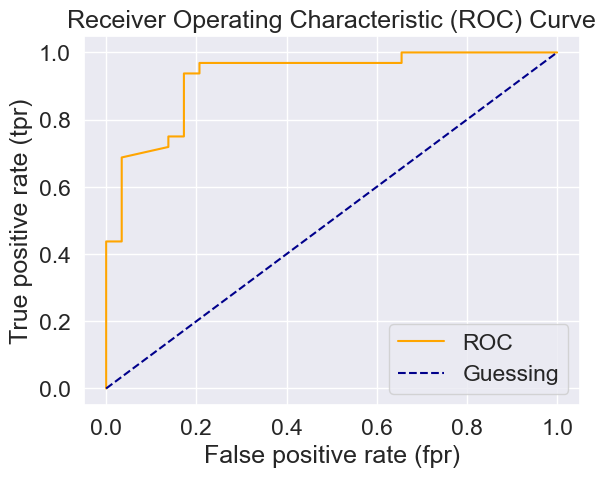

In [321]:
# Create a function for plotting ROC curves
import matplotlib.pyplot as plt

def plot_roc_curve(fpr , tpr) :
    """
        Plots a ROC curve given the false positive rate (fpr) & 
        true positive (tpr) of a model
    """

    # Plot roc curve 
    plt.plot(fpr , tpr , color="orange" , label="ROC")

    # Plot line with no predictive power (baseline) 
    plt.plot([0,1] , [0,1] , color="darkblue" , linestyle="--" , label="Guessing")

    # Customize the plot
    plt.xlabel("False positive rate (fpr)")
    plt.ylabel("True positive rate (tpr)")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

plot_roc_curve(fpr , tpr)

In [322]:
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_test , y_probs_positive))

0.9251077586206896


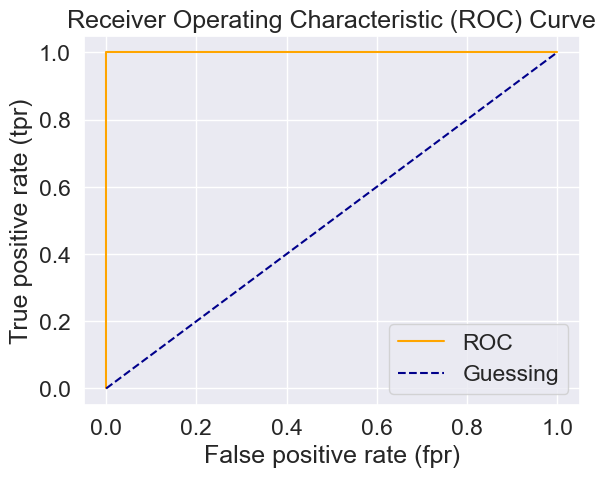

In [323]:
# Plot perfect ROC curve and AUC score
fpr , tpr , thresholds = roc_curve(y_test , y_test)
plot_roc_curve(fpr , tpr)

In [324]:
# Perfect AUC score 
print(roc_auc_score(y_test , y_test))

1.0


**Confusion Matrix**

A confusion matrix is a quick way to compare the labels a model predicts and the actual labels it was supposed to predict.

In essence , giving you an idea of where the model is getting confused.

In [325]:
from sklearn.metrics import confusion_matrix

y_preds = clf.predict(X_test)

confusion_matrix(y_test , y_preds)

array([[24,  5],
       [ 4, 28]])

In [326]:
# Visualize confusion matrix with pd.crosstab()

pd.crosstab(y_test , y_preds , rownames=["Actual label"] , colnames=["Predicted Labels"])

Predicted Labels,0,1
Actual label,,
0,24,5
1,4,28


In [327]:
24 + 5 + 3 + 29

61

In [328]:
len(y_preds)

61

In [329]:
# install conda package from jupyter
import sys
!conda install --yes --prefix {sys.prefix} seaborn

Channels:
 - defaults
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.



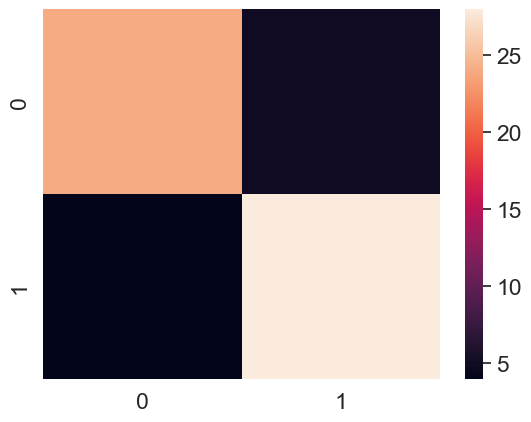

In [330]:
# Make our confusion matrix more visual with Seaborn's heatmap()
import seaborn as sns 

# Set the font scale 
sns.set(font_scale=1.5)

# Create a confusion matrix
conf_mat = confusion_matrix(y_test , y_preds)

# Plot using seaborn
sns.heatmap(conf_mat)

plt.show();

In [331]:
# Confusion matrix using Scikit-learn
clf

RandomForestClassifier()

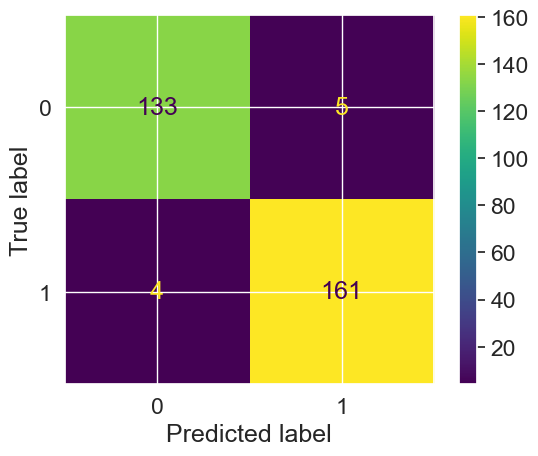

In [332]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(estimator=clf , X=X , y=y);
plt.show();

In [334]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [337]:
# Where precision and recall become valuable 
disease_true = np.zeros(10000)
disease_true[0] = 1 # only one positive case

disease_preds = np.zeros(10000) # model predicts every case as 0
pd.DataFrame(classification_report(disease_true,disease_preds,output_dict=True))

C:\Users\stfal\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\stfal\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\stfal\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.99990,0.0,0.9999,0.499950,0.99980
recall,1.00000,0.0,0.9999,0.500000,0.99990
f1-score,0.99995,0.0,0.9999,0.499975,0.99985
support,9999.00000,1.0,0.9999,10000.000000,10000.00000


To summarize classification metrics :

- **Accuracy** is good measure to start with if all classes are balanced .
- **Precision** and **recall** become more important when classes are imbalanced .
- If false positive predictions are worse than false negatives , aim for higher precision .
- If false negative prediction are worse than false positives , aim for higher recall .
- **F1-Score** is a combination of precision and recall .

### 4.2.2 Regression model evaluation metrics

The ones we're going to cover : 

1. R^2 (pronounced r-squared) or coefficient of determination
2. Mean absolute error (MAE)
3. Mean squared error (MSE)

In [339]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X = housing_df.drop("target" , axis = 1)
y = housing_df["target"]

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train , y_train)

RandomForestRegressor()

In [340]:
model.score(X_test , y_test)

0.806652667101436

In [343]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [344]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: target, Length: 4128, dtype: float64

In [342]:
y_test.mean()

np.float64(2.0550030959302323)

In [345]:
from sklearn.metrics import r2_score

# Fill an array with y_test mean 

y_test_mean = np.full(len(y_test) , y_test.mean())

In [346]:
y_test_mean[:10]

array([2.0550031, 2.0550031, 2.0550031, 2.0550031, 2.0550031, 2.0550031,
       2.0550031, 2.0550031, 2.0550031, 2.0550031])

In [347]:
r2_score(y_true=y_test, y_pred=y_test_mean)

0.0

In [355]:
r2_score(y_true=y_test , y_pred=y_test)

1.0

**Mean absolute error (MAE)**

MAE is the average of the absolute differences between predictions and actual values.

It gives you an ideea of how wrong your models predictions are 

In [356]:
from sklearn.metrics import mean_absolute_error
y_preds = model.predict(X_test)
mean_absolute_error(y_test,y_preds)

0.32656738464147306

In [359]:
df = pd.DataFrame(data={"actual values" : y_test , "predicted values" : y_preds})
df["differences"] = df["predicted values"] - df["actual values"]
df.head()

,actual values,predicted values,differences
20046,0.47700,0.493900,0.016900
3024,0.45800,0.754940,0.296940
15663,5.00001,4.928596,-0.071414
20484,2.18600,2.540240,0.354240
9814,2.78000,2.331760,-0.448240


In [361]:
# MAE using formula
np.abs(df["differences"]).mean()

np.float64(0.32656738464147306)

**Mean squared error (MSE)**

MSE is the mean of the square of the errors between actual and predicted values .


In [362]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test , y_preds)
mse

0.25336408094921037

In [363]:
df["squared_differences"] = np.square(df["differences"])
df.head()

,actual values,predicted values,differences,squared_differences
20046,0.47700,0.493900,0.016900,0.000286
3024,0.45800,0.754940,0.296940,0.088173
15663,5.00001,4.928596,-0.071414,0.005100
20484,2.18600,2.540240,0.354240,0.125486
9814,2.78000,2.331760,-0.448240,0.200919


In [365]:
# Calculate MSE by hand

squared = np.square(df["differences"])
print(squared.mean())

0.25336408094921037


In [366]:
df_large_error = df.copy()
df_large_error.iloc[0]["squared_differences"] = 16

C:\Users\stfal\AppData\Local\Temp\ipykernel_15736\3409892222.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_large_error.iloc[0]["squared_differences"] = 16


In [367]:
df_large_error

,actual values,predicted values,differences,squared_differences
20046,0.47700,0.493900,0.016900,16.000000
3024,0.45800,0.754940,0.296940,0.088173
15663,5.00001,4.928596,-0.071414,0.005100
20484,2.18600,2.540240,0.354240,0.125486
9814,2.78000,2.331760,-0.448240,0.200919
...,...,...,...,...
15362,2.63300,2.219830,-0.413170,0.170709
16623,2.66800,1.947760,-0.720240,0.518746
18086,5.00001,4.836378,-0.163632,0.026775
2144,0.72300,0.717820,-0.005180,0.000027


In [369]:
# Calculate MSE with large error 
print(df_large_error["squared_differences"].mean())

0.25723998075298943


In [370]:
df_large_error.iloc[1:100] = 20
df_large_error

,actual values,predicted values,differences,squared_differences
20046,0.47700,0.493900,0.016900,16.000000
3024,20.00000,20.000000,20.000000,20.000000
15663,20.00000,20.000000,20.000000,20.000000
20484,20.00000,20.000000,20.000000,20.000000
9814,20.00000,20.000000,20.000000,20.000000
...,...,...,...,...
15362,2.63300,2.219830,-0.413170,0.170709
16623,2.66800,1.947760,-0.720240,0.518746
18086,5.00001,4.836378,-0.163632,0.026775
2144,0.72300,0.717820,-0.005180,0.000027


In [372]:
print(df_large_error["squared_differences"].mean())

0.7333102979585939


### 4.2.3 Finally using the scoring parameter 

In [374]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop("target" , axis = 1)
y = heart_disease["target"]

clf = RandomForestClassifier(n_estimators=100)

In [375]:
np.random.seed(42)

# Cross-validation accuracy
cv_acc = cross_val_score(clf, X , y , cv=5 , scoring=None)
cv_acc

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [377]:
# Cross validated accuracy
print(f"The cross-validated accuracy is : {np.mean(cv_acc)*100:.2f}%")

The cross-validated accuracy is : 82.48%


In [378]:
np.random.seed(42)
ca_acc = cross_val_score(clf,X,y,cv=5,scoring="accuracy")
cv_acc

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [379]:
# Cross validated accuracy
print(f"The cross-validated accuracy is : {np.mean(cv_acc)*100:.2f}%")

The cross-validated accuracy is : 82.48%


In [380]:
# Precision
cv_precision = cross_val_score(clf,X,y,cv=5,scoring="precision")
cv_precision

array([0.76315789, 0.90322581, 0.83870968, 0.79411765, 0.74358974])

In [383]:
# Cross validated precision
print(f"The cross-validated precision is : {np.mean(cv_precision)}")

The cross-validated precision is : 0.8085601538512754


In [384]:
# Recall
cv_recall = cross_val_score(clf,X,y,cv=5,scoring="recall")
cv_recall

array([0.87878788, 0.84848485, 0.78787879, 0.78787879, 0.90909091])

In [385]:
# Cross validated recall
print(f"The cross-validated recall is : {np.mean(cv_recall)}")

The cross-validated recall is : 0.8424242424242424


Let's see the `scoring` parameter being using for a regression problem...

In [396]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X = heart_disease.drop("target" , axis = 1)
y = heart_disease["target"]

model = RandomForestRegressor(n_estimators=100)

In [398]:
np.random.seed(42)
cv_r2 = cross_val_score(model , X , y , cv=5 , scoring=None)
print(np.mean(cv_r2))

0.06436878552971577


In [401]:
# Mean squared error
cv_mse = cross_val_score(model , X , y , cv=5 , scoring="neg_mean_squared_error")
print(np.mean(cv_mse))

-0.1860146612021858


In [402]:
# Mean absolute error
cv_mae = cross_val_score(model , X , y , cv=5 , scoring="neg_mean_absolute_error")
print(np.mean(cv_mae))

-0.3309398907103825


# 4.3 Using different evaluation metrics as Scikit-Learn functions 
The 3rd way to evaluate scikit-learn machine learning models/estimators is to using the `sklearn.metrics` module 

In [411]:
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Create X and y 
X = heart_disease.drop("target" , axis = 1)
y = heart_disease["target"]

# Split the data 
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

# Create model
clf = RandomForestClassifier(n_estimators=100)

# Fit the model 
clf.fit(X_train , y_train)

# Make predictions
y_preds = clf.predict(X_test)

# Evaluate model using evaluation functions
print("Classifier metrics on the set")
print(f"Accuracy : {accuracy_score(y_test , y_preds)*100:.2f}%")
print(f"Precision : {precision_score(y_test , y_preds)}")
print(f"Recall : {recall_score(y_test , y_preds)}")
print(f"f1_score : {f1_score(y_test , y_preds)}")

Classifier metrics on the set
Accuracy : 85.25%
Precision : 0.8484848484848485
Recall : 0.875
f1_score : 0.8615384615384616


In [415]:
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Create X and y 
X = heart_disease.drop("target" , axis = 1)
y = heart_disease["target"]

# Split the data 
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

# Create model
model = RandomForestRegressor(n_estimators=100)

# Fit the model 
model.fit(X_train , y_train)

# Make prediction
y_preds = model.predict(X_test)

# Evaluate model using evaluation functions
print("Regressor model on the test set")
print(f"R^2 score : {r2_score(y_test , y_preds)}")
print(f"MAE : {mean_absolute_error(y_test , y_preds)}")
print(f"MSE : {mean_squared_error(y_test , y_preds)}")


Regressor model on the test set
R^2 score : 0.5106393318965518
MAE : 0.23754098360655734
MSE : 0.12204426229508197


## 5. Improving a model

First predictions = baseline predictions .
First model = baseline model . 

From a data perspective :
* Could we collect more data ? (generally , the more data , the better)
* Could we improve our data ?

From a model perspective :
* Is there a better model we could use ?
* Could we improve the current model ?

Parameters = model find these patterns in data 
Hyperparameters = settings on a model you can adjust to (potentially) improve its ability to find patterns 

Three ways to adjust hyperparameters : 
1. By hand
2. Randomly with RandomSearchCV
3. Exhaustively with GridSearchCV

In [416]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

In [417]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

### 5.1 Tunning hyperparameters by hand 

Let's make 3 sets , training , validation and test

We're going to try and adjust : 

* `max_depth`
* `max_features`
* `min_samples_leaf`
* `min_samples_split`
* `n_estimators`

In [423]:
def evaluate_preds(y_true , y_preds) :
    """
        Perform evaluation comparison on y_true labels vs. y_preds labels
        on a classification .
    """

    accuracy = accuracy_score(y_true , y_preds) 
    precision = precision_score(y_true , y_preds)
    recall = recall_score(y_true , y_preds)
    f1 = f1_score(y_true , y_preds)
    metric_dict = {"accuracy" : round(accuracy , 2),
                   "precision" : round(precision , 2),
                    "recall" : round(recall , 2),
                    "f1" : round(f1 , 2)}
    print(f"Acc : {accuracy * 100:.2f}%")
    print(f"Precision : {precision:.2f}")
    print(f"Recall : {recall:.2f}")
    print(f"F1 score : {f1:.2f}")

    return metric_dict

In [425]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

# Shuffle the data
heart_disease_shuffled = heart_disease.sample(frac=1)

# Split into X & y
X = heart_disease_shuffled.drop("target" , axis=1)
y = heart_disease_shuffled["target"]

# Split the data into train , validation & test sets 
train_split = round(0.7 * len(heart_disease_shuffled)) # 70% of data
valid_split = round(train_split + 0.15 * len(heart_disease_shuffled)) # 15% of data
X_train , y_train = X[:train_split] , y[:train_split]
X_valid , y_valid = X[train_split:valid_split] , y[train_split:valid_split]
X_test , y_test = X[valid_split:] , y[valid_split:]

len(X_train) , len(X_valid) , len(X_test)

(212, 45, 46)

In [426]:
clf = RandomForestClassifier()

clf.fit(X_train, y_train)

# Make baseline predictions
y_preds = clf.predict(X_valid)

# Evaluate the classifier on validation set
baseline_metrics =  evaluate_preds(y_valid , y_preds)
baseline_metrics

Acc : 75.56%
Precision : 0.73
Recall : 0.76
F1 score : 0.74


{'accuracy': 0.76, 'precision': 0.73, 'recall': 0.76, 'f1': 0.74}

In [427]:
# Create a second classifier with different hyperparameters
clf_2 = RandomForestClassifier(n_estimators=100)
clf_2.fit(X_train , y_train)

# Make predictions 
y_preds_2 = clf_2.predict(X_valid)

# Evaluate the 2nd classifier
clf_2_metrics = evaluate_preds(y_valid , y_preds_2)

Acc : 75.56%
Precision : 0.71
Recall : 0.81
F1 score : 0.76


### 5.2 Hyperparameter tuning with RandomizeSearchCV

In [441]:
from sklearn.model_selection import RandomizedSearchCV

grid = {"n_estimators" : [10,100,200,500,1000,1200],
        "max_depth" : [None,5,10,20,30],
        "max_features" : ["auto" , "sqrt"],
        "min_samples_split" : [2,4,6],
        "min_samples_leaf" : [1,2,4]}

np.random.seed(42)

# Split into X & y
X = heart_disease_shuffled.drop("target", axis=1)
y = heart_disease_shuffled["target"]

# Split into train and test sets
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

# Instantiate RandomForestClassifier
clf = RandomForestClassifier(n_jobs=1)

# Setup RandomizeSearchCV
rs_clf = RandomizedSearchCV(estimator=clf,
                            param_distributions=grid,
                            n_iter=10,#number the models to try
                            cv=5,
                            verbose=2)

# Fit the RandomizedSearchCV version of clf
rs_clf.fit(X_train, y_train);

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   1.5s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   1.3s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   1.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   1.1s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   1.1s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100

C:\Users\stfal\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\stfal\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\stfal\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\stfal\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 436, in _validate_params
    validat

In [434]:
 rs_clf.best_params_

{'n_estimators': 200,
 'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [435]:
# Make predictions with the best hyperparameters 
rs_y_preds = rs_clf.predict(X_test)

# Evaluate the predicitons 
rs_metrics = evaluate_preds(y_test,rs_y_preds)

Acc : 80.33%
Precision : 0.82
Recall : 0.82
F1 score : 0.82


### 5.3 Hyperparameter tunning with GridSearchCV

In [438]:
# it's like brute force (he will try every single combination)
grid

{'n_estimators': [10, 100, 200, 500, 1000, 1200],
 'max_depth': [None, 5, 10, 20, 30],
 'max_features': ['auto', 'sqrt'],
 'min_samples_split': [2, 4, 6],
 'min_samples_leaf': [1, 2, 4]}

In [448]:
grid_2 = {'n_estimators': [100, 200, 500],
          'max_depth': [None],
          'max_features': ['auto', 'sqrt'],
          'min_samples_split': [6],
          'min_samples_leaf': [1, 2]}

In [450]:
from sklearn.model_selection import GridSearchCV , train_test_split

np.random.seed()

# Split into X & y
X = heart_disease_shuffled.drop("target", axis=1)
y = heart_disease_shuffled["target"]

# Split into train and test sets
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

# Instantiate RandomForestClassifier
clf = RandomForestClassifier(n_jobs=1)

# Setup RandomizeSearchCV
gs_clf = GridSearchCV(estimator=clf,
                      param_grid=grid_2,
                      cv=5,
                      verbose=2)

# Fit the GridSearchCV version of clf
gs_clf.fit(X_train, y_train);

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, 

C:\Users\stfal\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\stfal\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\stfal\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\stfal\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 436, in _validate_params
    validat

In [453]:
gs_clf.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 6,
 'n_estimators': 500}

In [454]:
gs_y_preds = gs_clf.predict(X_test)

#evaluate the predictions
gs_metrics = evaluate_preds(y_test , gs_y_preds)

Acc : 85.25%
Precision : 0.88
Recall : 0.85
F1 score : 0.87


Let's compare our different models metrics

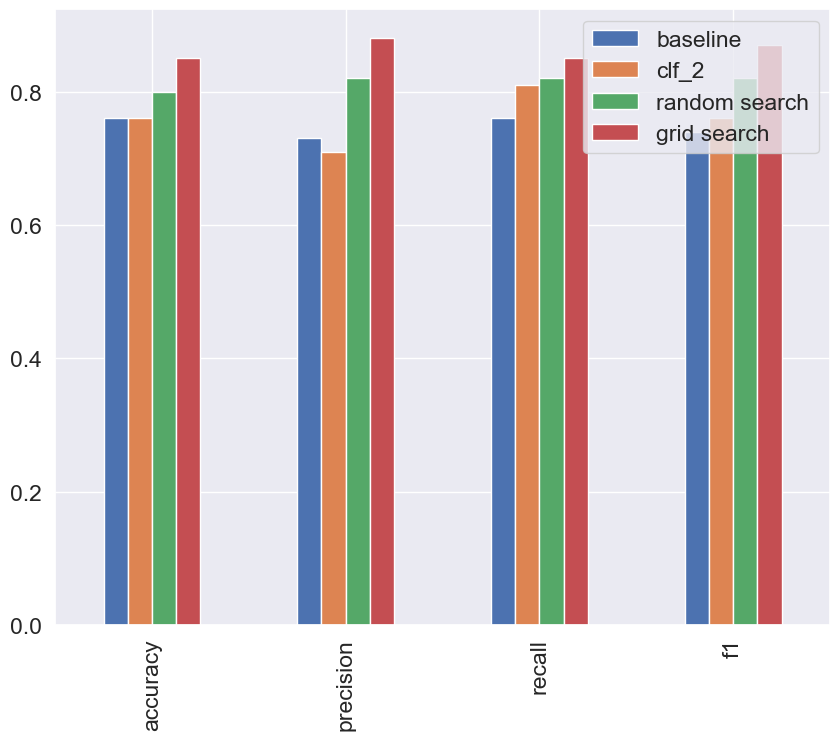

In [458]:
compare_metrics = pd.DataFrame({"baseline" : baseline_metrics,
                                "clf_2" : clf_2_metrics,
                                "random search" : rs_metrics,
                                "grid search" : gs_metrics})

compare_metrics.plot.bar(figsize=(10,8));
plt.show();

### 6. Saving and loading trained machine learning models

Two ways to save and load machine learning models : 
1. With Python's `pickle` module
2. With the `joblib` module

**Pickle** - serializing and de-serializing

In [459]:
import pickle

# Save an existing model to file
pickle.dump(gs_clf , open("gs_random_random_forest_model_1.pkl", "wb"))

In [460]:
# Load a saved model 
loaded_pickle_model = pickle.load(open("gs_random_random_forest_model_1.pkl" , "rb"))

In [462]:
# Make some predictions
pickle_y_preds = loaded_pickle_model.predict(X_test)

evaluate_preds(y_test , pickle_y_preds)

Acc : 85.25%
Precision : 0.88
Recall : 0.85
F1 score : 0.87


{'accuracy': 0.85, 'precision': 0.88, 'recall': 0.85, 'f1': 0.87}

**Joblib**

In [463]:
from joblib import dump , load

# Save model to file
dump(gs_clf , filename="gs_random_random_forest_model_1.joblib")

['gs_random_random_forest_model_1.joblib']

In [465]:
# Import a saved joblib model 
loaded_joblib_model = load(filename="gs_random_random_forest_model_1.joblib")

In [469]:
# Make and evaluate joblib predictions 
joblib_y_preds = loaded_joblib_model.predict(X_test)

evaluate_preds(y_test , joblib_y_preds)

Acc : 85.25%
Precision : 0.88
Recall : 0.85
F1 score : 0.87


{'accuracy': 0.85, 'precision': 0.88, 'recall': 0.85, 'f1': 0.87}

### 7. Putting it all together ! 

In [470]:
data = pd.read_csv("./csv_datasets/scikit-learn-data/car-sales-extended-missing-data.csv")

In [471]:
data

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [472]:
data.dtypes

Make              object
Colour            object
Odometer (KM)    float64
Doors            float64
Price            float64
dtype: object

In [473]:
data.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

Steps we want to do (all in one cell) :
1. Fill missing data
2. Convert data to numbers
3. Build a model on the data

In [484]:
# Getting data ready
import pandas as pd 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Modeling
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split , GridSearchCV

# Setup random seed
import numpy as np
np.random.seed(42)

# Import data and drop rows with missing labels
data = pd.read_csv("./csv_datasets/scikit-learn-data/car-sales-extended-missing-data.csv")
data.dropna(subset=["Price"] , inplace=True)

# Define different features and transformer pipeline
categorical_features = ["Make" , "Colour"]
categorical_transformer = Pipeline(steps = [
    ("imputer" , SimpleImputer(strategy="constant" , fill_value="missing")),
    ("onehot" , OneHotEncoder(handle_unknown="ignore"))
])

door_features = ["Doors"]
door_transformer = Pipeline(steps=[
    ("imputer" , SimpleImputer(strategy="constant" , fill_value=4)),
])

numerical_features = ["Odometer (KM)"]
numerical_transformer = Pipeline(steps=[
    ("imputer" , SimpleImputer(strategy='mean'))
])

# Setup the preprocessing steps (fill missing data , then convert to numbers )
preprocessor = ColumnTransformer(
      transformers=[
          ("cat" , categorical_transformer , categorical_features),
          ("door" , door_transformer , door_features),
          ("num" , numerical_transformer , numerical_features)
      ]
)

# Create a preprocessing and modeling pipeline
model = Pipeline(steps=[("preprocessor" , preprocessor),
                        ("model" , RandomForestRegressor())])

# Split data
X = data.drop("Price" , axis=1)
y = data["Price"]
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

# Fit and score the model 
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.22188417408787875

It's also possible to use `GridSearchCV` or `RandomizedSearchCV` with our `Pipeline`

In [485]:
# Use GridSearchCV with our Pipeline
from sklearn.model_selection import GridSearchCV

pipe_grid = {
    "preprocessor__num__imputer__strategy" : ["mean" , "median"],
    "model__n_estimators" : [100,1000],
    "model__max_depth" : [None , 5],
    "model__max_features" : ["sqrt","log2"],
    "model__min_samples_split" : [2,4]
}

gs_model = GridSearchCV(model , pipe_grid , cv=5 , verbose=2)
gs_model.fit(X_train , y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samp

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='missing',
                                                                                                        strategy='constant')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Make',
                                                                          'Colour']),
                                                                        ('door',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value=4,
                                                                                                        strategy='constant'))]),
                                                                         ['Doors']),
                                                                        ('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['Odometer '
                                                                          '(KM)'])])),
                                       ('model', RandomForestRegressor())]),
             param_grid={'model__max_depth': [None, 5],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_split': [2, 4],
                         'model__n_estimators': [100, 1000],
                         'preprocessor__num__imputer__strategy': ['mean',
                                                                  'median']},
             verbose=2)

In [486]:
gs_model.score(X_test , y_test)

0.28553567798887214